# Titanic Survival Prediction

## 1. Problem Definition

Predict whether a passenger survived the Titanic disaster based on passenger attributes. 

## 2. Data Loading

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


In [2]:
df = pd.read_csv("../data/Titanic_train.csv")

## 3. Feature Engineering

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

In [4]:
#let's check everything went well
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [5]:
#let's encode categorical variables
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [6]:
#let's drop unnecessary columns
df = df.drop(columns=["Name", "Ticket", "PassengerId"])

In [7]:
#let's convert boolean columns to integers
df["Embarked_Q"] = df["Embarked_Q"].astype(int)
df["Embarked_S"] = df["Embarked_S"].astype(int)

In [8]:
#let's check our final dataset
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


- Our target variable: Survived
- Our features:
    - Numerical: Age, Fare
    - Encoded categorial: Sex, Pclass, Embarked
    - Count features: SibSp, Parch
- No missing values
- All variables are numeric
- Ready for machine learning

## 4. Model Training

Will use logistic regression from scikit-learn

In [10]:
#let's split features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [11]:
#let's train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
#let's train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
#let's evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


Once EDA + modelling loop is completed, we can start looking beyong accuracy as it can hide problems like class imbalance, etc. 

In [14]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df.style.background_gradient(cmap="Blues"))

,Predicted 0,Predicted 1
Actual 0,90,15
Actual 1,19,55


In [15]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

display(report_df.style.background_gradient(cmap="Greens").format("{:.2f}"))

,precision,recall,f1-score,support
0,0.83,0.86,0.84,105.00
1,0.79,0.74,0.76,74.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.81,0.80,0.80,179.00
weighted avg,0.81,0.81,0.81,179.00


In [16]:
#let's see feature impact
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coeffs

,Feature,Coefficient
1,Sex,2.590161
5,Fare,0.002576
2,Age,-0.030551
4,Parch,-0.107571
6,Embarked_Q,-0.112163
3,SibSp,-0.295059
7,Embarked_S,-0.399364
0,Pclass,-0.938096


Interpretation:
- Being female increases survival probability.
- Lower class has lower survival probability which means a strong socioeconomic effect.
- The higher the fare the slightly higher survival probability but it's effect is weaker than Pclass.
- Older passengers are slightly less likely to survive. It is a week feature. 
- For larger families there is low probability of surviving.

From strongest to weakest:

1. Sex 
2. Pclass
3. Family features 
4. Age 
5. Fare 
6. Embarked 

In [17]:
#let's scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Scaled Accuracy:", accuracy_score(y_test, y_pred))

Scaled Accuracy: 0.8100558659217877


In [18]:
#let's try a non-linear model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7988826815642458


Let's test a hypothesis: Family structure affects survival.

In [19]:
#let's create feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [20]:
#let's drop old features
df = df.drop(columns=["SibSp", "Parch"])

In [21]:
#let's check everything went well
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,7.2500,0,1,2
1,1,1,1,38.0,71.2833,0,0,2
2,1,3,1,26.0,7.9250,0,1,1
3,1,1,1,35.0,53.1000,0,1,2
4,0,3,0,35.0,8.0500,0,1,1


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked_Q  891 non-null    int64  
 6   Embarked_S  891 non-null    int64  
 7   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [23]:
#let's repeat train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
#let's re-train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
#let's re-evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


## 5. Model Evaluation

Feature engineering did not improve the model performance. Not every engineered feature improves model performance. Let's see if we are evaluating our model correctly. 

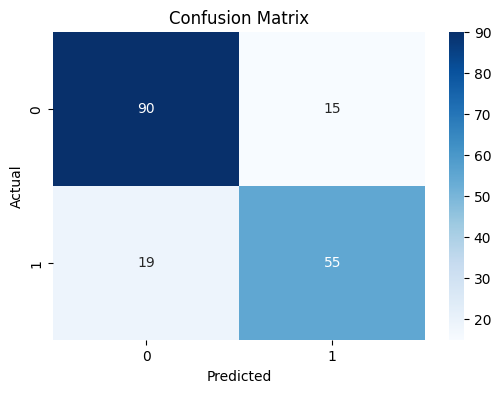

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient(cmap="Greens")

,precision,recall,f1-score,support
0,0.825688,0.857143,0.841121,105.000000
1,0.785714,0.743243,0.763889,74.000000
accuracy,0.810056,0.810056,0.810056,0.810056
macro avg,0.805701,0.800193,0.802505,179.000000
weighted avg,0.809163,0.810056,0.809193,179.000000


Interpretation:
- Out of 105, we've got 15 incorrectly predicted as survivors.
- Out of 74, we've got 19 wrongly predicted as no survivors. 

For no survivors we have a 0.79 precision and 0.74 recall which means we are missing some survivors (false negatives).
26% of survivors are being incorrectly predicted as no survivors. 

Predicting survivors incorrectly (false negatives) is more costly than the false positives. 

So far we've evalutated our model using one train/test split. This has a problem: our accuracy might be a little lucky depending on the split. Here is when cross-validation comes in handy. It fixes this by testing the model multiple times on different splits. Instead of tain/test split once, we do multiple splits, or folds. 

In [28]:
#let's run cross-validation
model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=5)

print("CV scores:", scores)
print("Mean accuracy:", np.mean(scores))
print("Std:", np.std(scores))

CV scores: [0.7877095  0.78651685 0.78651685 0.76966292 0.8258427 ]
Mean accuracy: 0.7912497646098802
Std: 0.018547221505865137


The earlier 0.81 accuracy was a little optimistic. It came from a single train/test split and that split was a bit favorable. 
Standard deviation is low, which means that performance is consistent across different splits and the model is not fragile. 
Our evaluation is now realistic. 

Let's compare our models properly using cross-validation. 

In [29]:
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [30]:
log_scores = cross_val_score(log_model, X, y, cv=5)
rf_scores = cross_val_score(rf_model, X, y, cv=5)

print("Logistic Regression CV Mean:", np.mean(log_scores))
print("Random Forest CV Mean:", np.mean(rf_scores))

print("Logistic Std:", np.std(log_scores))
print("RF Std:", np.std(rf_scores))

Logistic Regression CV Mean: 0.7912497646098802
Random Forest CV Mean: 0.8081036971941498
Logistic Std: 0.018547221505865137
RF Std: 0.026968942517790948


Interpretation:

We can see that Random Forest is better in this case, which means that there are nonlinear patterns in the data and interactions between features matter. 
Random Forest is also less stable, this implies that performance varies more across folds and the model is sensitive to data splits by a small margin. 

The dataset is partly linear (Sex, Pclass), partly nonlinear (Sex x Class, Age x Class, Familiy structure). Random Forest captures these interactions better. 

Let's run Feature importance (Random Forest) and answer the folliwng question: Why is the model making these predictions?

In [31]:
rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,Sex,0.269022
5,Fare,0.267476
2,Age,0.261095
0,Pclass,0.083440
3,SibSp,0.050469
4,Parch,0.037909
7,Embarked_S,0.020481
6,Embarked_Q,0.010108


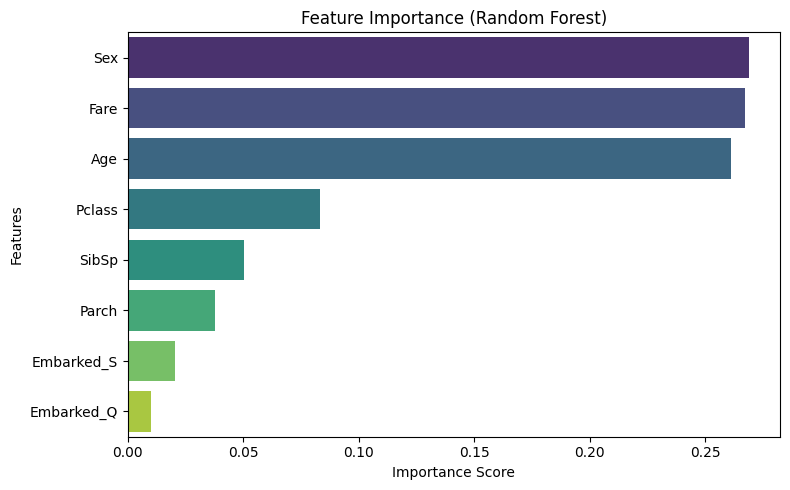

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    hue="Feature",
    data=feature_importance,
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("../reports/feature_importance.png")

plt.show()

## 6. Conclusion

Our model is dominated by 3 features that outpower the rest:

- Sex
- Fare
- Age

These features together represent the 80% of total importance. 

    a) Wealth signaling is a more complex construct than simple class stratification.
    b) Age has nonlinear effects that logistic regression is unable to adequately capture.
    c) Pclass is in part redundant once Fare is included.
    d) Interactions between features are important.